как применять Python в e-commerce аналитике.
основная ценность вебинара - собрать данные. 
вебинар 21.07.25 Симулятив Андрон Алексанян
ссылка но [гугл_коллаб](https://colab.research.google.com/drive/1HVyMnQszohWeTxtlW606b1pl693egu4S?usp=sharing)

этот кейс с поисковым движком WB
поищем сырые данные

![](images/0001.png)

In [14]:
# import pandas as pd
import requests
from datetime import datetime

In [3]:
page = 1

query = 'лонгслив женский оверсайз'
res = requests.get(f"https://search.wb.ru/exactmatch/ru/female/v9/search?ab_testing=false&appType=64&curr=rub&dest=123585762&hide_dtype=13&lang=ru&page={page}&query={query}&resultset=catalog&sort=popular")

In [5]:
# мешает - поэтому закоммент
# res.json()

In [57]:
arr = []

In [58]:
query_list = ['лонгслив женский оверсайз',
             'лонгслив женский']
max_page = 3
brand = 'ТЕЛОДВИЖЕНИЯ'

for query in query_list:
    for page in range(1, max_page +1):
        res = requests.get(f"https://search.wb.ru/exactmatch/ru/female/v9/search?ab_testing=false&appType=64&curr=rub&dest=123585762&hide_dtype=13&lang=ru&page={page}&query={query}&resultset=catalog&sort=popular")
        for card in res.json()['data']['products']:
            if card.get('log') and card['brand'] == brand:
                arr.append([
                    card['log']['position'],
                    card['log']['promoPosition'],
                    datetime.now(),
                    query,
                    card['name']
                    ])
                # print(card['log'])
        # print(f"query:{query}, page: {page}")

In [59]:
# список карточек
# res.json()['data']['products'][1]['log']

In [60]:
import pandas as pd
df = pd.DataFrame(arr)
df.columns = ['position', 'promo_position', 'created_at', 'query', 'name']
df

,position,promo_position,created_at,query,name
0,364,26,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
1,296,60,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
2,298,61,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
3,297,62,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
4,364,66,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз набор 2 шт
5,324,74,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
6,333,75,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив свободный оверсайз с длинным рукавом
7,334,78,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
8,339,86,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом
9,351,87,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз набор 2 шт


In [61]:
df['dif'] = df['position'] - df['promo_position']
df['hour'] = df['created_at'].dt.hour
df['hour'] = df['created_at'].dt.day
df

,position,promo_position,created_at,query,name,dif,hour
0,364,26,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,338,21
1,296,60,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,236,21
2,298,61,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,237,21
3,297,62,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,235,21
4,364,66,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз набор 2 шт,298,21
5,324,74,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,250,21
6,333,75,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив свободный оверсайз с длинным рукавом,258,21
7,334,78,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,256,21
8,339,86,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,253,21
9,351,87,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз набор 2 шт,264,21


In [65]:
df1 = df[df['name'] == 'Лонгслив женский оверсайз с длинным рукавом']
df1

,position,promo_position,created_at,query,name,dif,hour
0,364,26,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,338,21
1,296,60,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,236,21
2,298,61,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,237,21
3,297,62,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,235,21
5,324,74,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,250,21
7,334,78,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,256,21
8,339,86,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,253,21
10,348,88,2025-07-21 19:47:54.407636,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,260,21
12,688,132,2025-07-21 19:47:55.503156,лонгслив женский оверсайз,Лонгслив женский оверсайз с длинным рукавом,556,21
15,710,38,2025-07-21 19:47:58.926327,лонгслив женский,Лонгслив женский оверсайз с длинным рукавом,672,21


In [66]:
pd.pivot_table(
    df1,
    index='query',
    columns ='hour',
    values='promo_position',
    aggfunc='mean'
)

hour,21
query,
лонгслив женский,165.500000
лонгслив женский оверсайз,74.111111


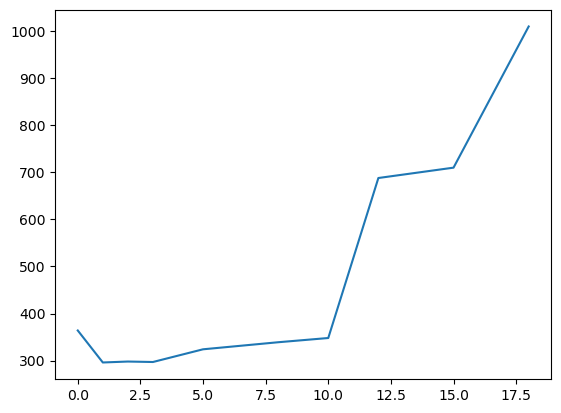

In [67]:
import matplotlib.pyplot as plt
plt.plot(df1['position']);